In [2]:
# =========================
# 1. Import Libraries
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set(style="whitegrid")


# =========================
# 2. Load Dataset
# =========================
df = pd.read_csv(r'C:\Users\FA23-BCS-041.CUI\Desktop\datasets\enhanced_health_insurance_claims.csv')  # change filename if needed

print(df.head())
print(df.info())


                                ClaimID                             PatientID  \
0  10944daf-f7d5-4e1d-8216-72ffa609fe41  8552381d-7960-4f64-b190-b20b8ada00a1   
1  fcbebb25-fc24-4c0f-a966-749edcf83fb1  327f43ad-e3bd-4473-a9ed-46483a0a156f   
2  9e9983e7-9ea7-45f5-84d8-ce49ccd8a4a1  6f3acdf7-73aa-4afa-9c2e-b25b27bdb5b0   
3  a06273ed-44bb-452b-bbad-8618de080494  5d58e183-701e-406c-a8c6-5b73cac5e912   
4  f702a717-254b-4cff-a0c7-8395db2f6616  8a8ebdf6-3af0-4f14-82f3-37b937c3d270   

                             ProviderID  ClaimAmount   ClaimDate  \
0  4a4cb19c-4863-41cf-84b0-c2b21aace988      3807.95  2024-06-07   
1  422e02dd-c1fd-43dd-8af4-0c3523f997b1      9512.07  2023-05-30   
2  f7733b3f-0980-47b5-a7a0-ee390869355b      7346.74  2022-09-27   
3  f7a04581-de96-44ee-b773-8adac02baa59      6026.72  2023-06-25   
4  b80b9e77-97f0-47d7-b561-19f9658a7bdf      1644.58  2023-07-24   

  DiagnosisCode ProcedureCode  PatientAge PatientGender ProviderSpecialty  \
0         yy006         hd6

In [3]:
# =========================
# 3. Drop useless ID columns
# =========================
# These do NOT help prediction (they are just identifiers)
df = df.drop(columns=["ClaimID", "PatientID", "ProviderID"])


# =========================
# 4. Convert Date Feature
# =========================
df["ClaimDate"] = pd.to_datetime(df["ClaimDate"])

df["ClaimYear"] = df["ClaimDate"].dt.year
df["ClaimMonth"] = df["ClaimDate"].dt.month

df = df.drop(columns=["ClaimDate"])


# =========================
# 5. Handle Missing Values (if any)
# =========================
print(df.isnull().sum())

df = df.dropna()   # simple approach for internship level



ClaimAmount                0
DiagnosisCode              0
ProcedureCode              0
PatientAge                 0
PatientGender              0
ProviderSpecialty          0
ClaimStatus                0
PatientIncome              0
PatientMaritalStatus       0
PatientEmploymentStatus    0
ProviderLocation           0
ClaimType                  0
ClaimSubmissionMethod      0
ClaimYear                  0
ClaimMonth                 0
dtype: int64


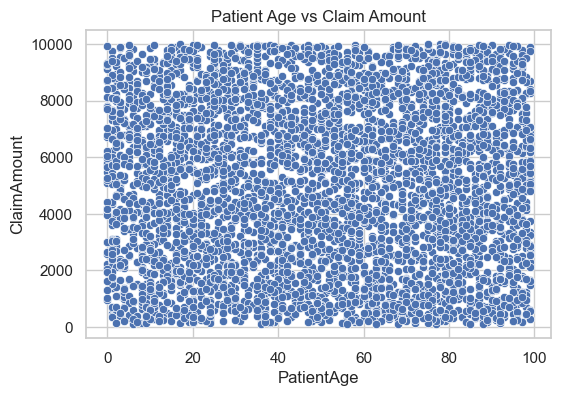

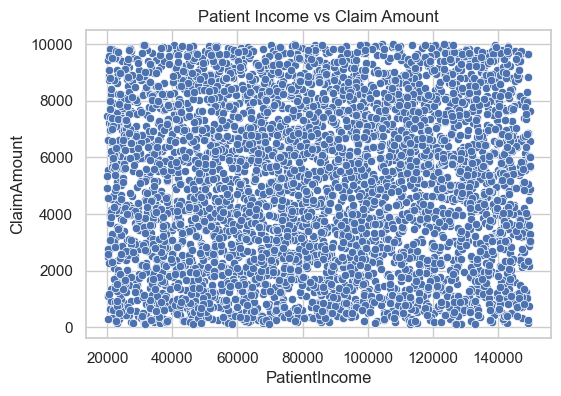

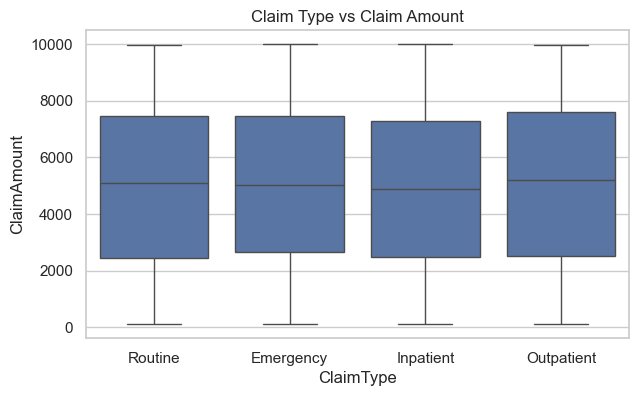

In [4]:
# =========================
# 6. Exploratory Visualization
# =========================

# Age vs ClaimAmount
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["PatientAge"], y=df["ClaimAmount"])
plt.title("Patient Age vs Claim Amount")
plt.show()


# Income vs ClaimAmount
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["PatientIncome"], y=df["ClaimAmount"])
plt.title("Patient Income vs Claim Amount")
plt.show()


# Claim Type impact
plt.figure(figsize=(7,4))
sns.boxplot(x=df["ClaimType"], y=df["ClaimAmount"])
plt.title("Claim Type vs Claim Amount")
plt.show()


# =========================
# 7. Encode Categorical Variables
# =========================
categorical_cols = [
    "PatientGender",
    "ProviderSpecialty",
    "ClaimStatus",
    "PatientMaritalStatus",
    "PatientEmploymentStatus",
    "ProviderLocation",
    "ClaimType",
    "ClaimSubmissionMethod",
    "DiagnosisCode",
    "ProcedureCode"
]

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)


Model Performance:
MAE  = 2485.788990343873
RMSE = 2886.0204559191347

Top Positive & Negative Factors:
                   Feature       Impact
9498   ProcedureCode_Mh382  2791.439749
5948   DiagnosisCode_Xj052  2791.439749
12412  ProcedureCode_uP113  2748.987352
7484   DiagnosisCode_pR126  2748.987352
8465   ProcedureCode_BA336  2540.962519
3989   DiagnosisCode_BA220  2540.962519
9752   ProcedureCode_Pc197  2449.977445
7674   DiagnosisCode_rc106  2449.977445
11853  ProcedureCode_nx468  2434.650008
7509   DiagnosisCode_pk561  2434.650008


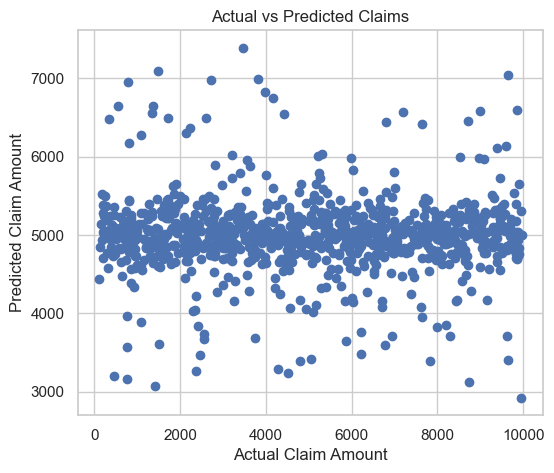

In [5]:
# =========================
# 8. Split Data
# =========================
X = df_encoded.drop("ClaimAmount", axis=1)
y = df_encoded["ClaimAmount"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# =========================
# 9. Train Linear Regression Model
# =========================
model = LinearRegression()
model.fit(X_train, y_train)


# =========================
# 10. Predictions
# =========================
y_pred = model.predict(X_test)


# =========================
# 11. Evaluation (MAE + RMSE)
# =========================
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nModel Performance:")
print("MAE  =", mae)
print("RMSE =", rmse)


# =========================
# 12. Feature Impact (Most Important Drivers)
# =========================
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Impact": model.coef_
})

coefficients = coefficients.sort_values(by="Impact", ascending=False)

print("\nTop Positive & Negative Factors:")
print(coefficients.head(10))


# =========================
# 13. Actual vs Predicted
# =========================
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Claim Amount")
plt.ylabel("Predicted Claim Amount")
plt.title("Actual vs Predicted Claims")
plt.show()